# Interpolação de Newton e Interpolação de Gregory-Newton

# 1. Interpolação via matriz de Vandermonde

O código a seguir ilustra como obter os coeficientes de um polinômio interpolador para um dado conjunto de valores através da resolução do sistema linear com a matriz dos coeficientes A de **Vandermonde**.


>$A x = b \rightarrow
 \begin{pmatrix}
  1 & x_0 & \cdots & x_0^n \\
  1 & x_1 & \cdots & x_1^n \\
  \vdots  & \vdots & \ddots & \vdots  \\
  1 & x_n & \cdots & x_n^n
 \end{pmatrix} 
 \begin{pmatrix}
  a_0 \\
  a_1 \\
  \vdots   \\
  a_n
 \end{pmatrix}
 =
 \begin{pmatrix}
  f(x_0) \\
  f(x_1) \\
  \vdots   \\
  f(x_n)
 \end{pmatrix}
 $

 onde: $x_i, \forall i = 0, 1, ..., n$ são os **n+1 pontos** distintos de **f(x)**.
 
A solução desse sistema com **n+1 equações** e **n+1 variáveis** irá resultar na obtenção dos coeficientes do seguinte polinômio de **grau n**: 
 
 $p_n(x) = a_0 + a_1x + a_2x^2 + ... + a_nx^n$. 


> O polinômio $p_n(x)$ é uma aproximação **g(x)** da função **f(x)**.

*OBS: Mais informações sobre a matriz de Vandermode:* https://pt.wikipedia.org/wiki/Matriz_de_Vandermonde

In [ ]:
import numpy as np

def sistemaVander(x,y):
  n = len(x)
  A = np.empty((n,n))
  b = np.empty((n))
  for i in range(0,n):
    A[i,0] = 1  
    for j in range(1,n):
      A[i,j] = A[i,j-1]*x[i]
    b[i]   = y[i]

  return A, b 

# Dados do problema.
x  = [-1, 0, 2]
y  = [4, 1, -1]
A, b = sistemaVander(x,y)
x  = np.linalg.solve(A,b)
print(A)
print(b)
print(x)
print(" ")
print("Polinômio interporlador obtido:")
n = len(x)
s = ""
for i in range(0,n):
  if (i < (n-1)):
    s = s + (str(x[i])+"*x^"+str(i)+" + ")
  else:
    s = s + str(x[i])+"*x^"+str(i)
    print(s) 

[[ 1. -1.  1.]
 [ 1.  0.  0.]
 [ 1.  2.  4.]]
[ 4.  1. -1.]
[ 1.         -2.33333333  0.66666667]
 
Polinômio interporlador obtido:
0.9999999999999996*x^0 + -2.3333333333333335*x^1 + 0.6666666666666667*x^2


# 2. Interpolação via forma de Lagrange

Ao invés de obter explicitamente a expressão da função g(x) que interpola f(x) em um conjunto de pontos dados, este programa usa uma forma implícita. Nessa forma implícita basta fornecer o valor xp para se obter o valor g(xp) correspondente.

A expressão geral do polinômio de **grau n** na forma de Lagrange é dada por:

$p_n(x) = \displaystyle \sum_{k=0}^N y_k L_k(x)$

onde:

$L_k(x) = \frac{\displaystyle\prod_{j=0,j \neq k}^{n} (x - x_j)}{\displaystyle\prod_{j=0,j \neq k}^{n} (x_k - x_j)}$

Por exemplo, sejam os dados fornecidos pela seguinte tabela:


>  x | -1  |  0  |  2
>--- | --- | --- | ---
>f(x)|  4  |  1  | -1


Um polinômio de grau 2, na forma de Lagrange, que interpola nos 3 pontos dados será obtido com:


$p_2(x) = y_0L_0(x) + y_1L_1(x) + y_2L_2(x)$

onde:

$L_0(x) = \frac{(x - x_1) (x - x_2)}{ (x_0 - x_1) (x_0 - x_2)}$,

$L_1(x) = \frac{(x - x_0) (x - x_2)}{ (x_1 - x_0) (x_1 - x_2)}$,

$L_2(x) = \frac{(x - x_0) (x - x_1)}{ (x_2 - x_0) (x_2 - x_1)}$



g(0.500) = 0.000


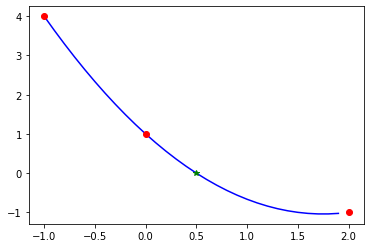

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def interpLagrange(xp,x,y,grau): 
  # Valor inicial de g(xp).
  yp = 0
  # Interpolação de Lagrange
  for k in range(0,n+1):  
    p = 1
    for j in range(0,n+1):
      if k != j:
        p = p*(xp - x[j])/(x[k] - x[j])
    
    yp = yp + p * y[k]  

  return yp  

# Dados do problema.
x = [-1, 0, 2]
y = [4, 1, -1]

# Ponto da interpolação
#xp = float(input('Entre com xp: ')) #caso queiram inserir manualmente o valor de xp
xp = 0.5
# Grau da interpolação.
n = 2
# Interpolação de Lagrange.
yp = interpLagrange(xp,x,y,n)

# Valor interpolado encontrado
print('g(%.3f) = %.3f' % (xp, yp))

t  = np.arange(-1.0, 2.0, 0.1)
yt = []
for i in t:
  yt.append(interpLagrange(i,x,y,n))
plt.plot(t,yt,'b-')
plt.plot(x,y,'ro')
plt.plot(xp,yp,'g*')
plt.show()

# 3. Interpolação forma de Newton (usa diferenças divididas)

O programa a seguir fornece o cálculo da interpolação através do cálculo de diferenças divididas e o uso do produto de variáveis para cálculo dos sucessivos coeficientes do polinômio para avaliação em um dado **xp**.


As diferenças divididas podem ser encontradas obtendo-se a seguinte tabela:


Por exemplo, a partir de 3 coordenadas $(x,f(x))$ é possível construir a seguinte tabela:


>  x  | Ordem 0 (f(x))|  ------------------Ordem 1-------------------   |  --------------------Ordem 2-----------------------
>---  | ---            | ---    | ---
>  -1 |  $f[x_0] = 4$  |$f[x_0,x_1]=(f[x_1]-f[x_0])/(x_1-x_0) = (1-4)/(0+1) = -3$        |  
>   0 |  $f[x_1] = 1$  |  | $f[x_0, x_1, x_2] = 
(f[x_1, x_2]-f[x_0, x_1])/(x_2-x_0)=
(-1+3)/(2+1) = 2/3$
>   2 |  $f[x_2]-1$    | $f[x_1,x_2]=(f[x_2]-f[x_1])/(x_2-x_1) = (-1-1)/(2-0) = -1$       | 


O segundo passo é calcular a expressão $p_n(x)$ através das diferenças divididas dada por:

$p_n(x) = f(x_0) + (x - x_0) f[x_0,x_1] + (x - x_0)(x - x_1)f[x_0,x_1,x_2] + ...+ (x - x_0)(x - x_1)...(x - x_{n-1}) f[x_0,x_1,...,x_n]$.

Para o exemplo dado:

$p_2(x) = 4 + (x - (-1)) (-3) + (x - (-1))(x - (0))(2/3) = 1 - 7/3x + 2/3x^2$






# Exemplo (1): 
Para os valores tabelados abaixo, encontre f(0.5), f(-0.5) e f(1.5) utilizando o método de interpolação de Newton.

>  x | -1  |  0  |  2
>--- | --- | --- | ---
>f(x)|  4  |  1  | -1



In [15]:
##Interpolação de Newton 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def interpNewton(x, y, xi):
  #Número de dados
  n = len(x)
  #Inicialização da diferença dividida: n x n
  fdd = [[None for x in range(n)] for x in range(n)]
  #Valores da função f(X) em vários pontos
  yint = [None for x in range(n)]
    
  #Encontrando diferenças divididas.
  for i in range(n):
    fdd[i][0] = y[i]
  for j in range(1,n):
    for i in range(n-j):
      fdd[i][j] = (fdd[i+1][j-1] - fdd[i][j-1])/(x[i+j]-x[i])
    
  # Imprimindo diferenças divididas.
  fdd_table = pd.DataFrame(fdd)
  print(fdd_table)
    
  #Interpolação para xi.
  xterm = 1
  yint = fdd[0][0]
  for order in range(1, n):
    xterm = xterm * (xi - x[order-1])
    yint = yint + fdd[0][order]*xterm
    
  #Retornando g(xi).
  return yint


x  = [-1, 0, 2]
y  = [4, 1, -1]
xp = 0.5
#xp = -0.5
#xp = 1.5
yp = interpNewton(x, y, xp)

# Valor interpolado encontrado
print('g(%.3f) = %.3f' % (xp, yp))


   0    1         2
0  4 -3.0  0.666667
1  1 -1.0       NaN
2 -1  NaN       NaN
g(0.500) = 0.000


g(0.500) = 0.000


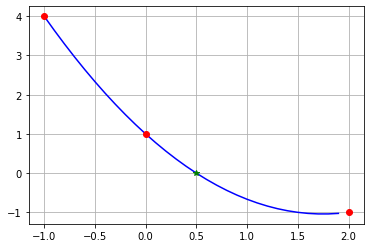

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def interpNewton(x, y, xi):
  #Número de dados
  n = len(x)
  #Inicialização da diferença dividida: n x n
  fdd = [[None for x in range(n)] for x in range(n)]
  #Valores da função f(X) em vários pontos
  yint = [None for x in range(n)]
    
  #Encontrando diferenças divididas.
  for i in range(n):
    fdd[i][0] = y[i]
  for j in range(1,n):
    for i in range(n-j):
      fdd[i][j] = (fdd[i+1][j-1] - fdd[i][j-1])/(x[i+j]-x[i])
    
  # Imprimindo diferenças divididas.
  fdd_table = pd.DataFrame(fdd)
  #print(fdd_table)
    
  #Interpolação para xi.
  xterm = 1
  yint = fdd[0][0]
  for order in range(1, n):
    xterm = xterm * (xi - x[order-1])
    yint = yint + fdd[0][order]*xterm
    
  #Retornando g(xi).
  return yint


x  = [-1, 0, 2]
y  = [4, 1, -1]
xp = 0.5
yp = interpNewton(x, y, xp)

# Valor interpolado encontrado
print('g(%.3f) = %.3f' % (xp, yp))

t  = np.arange(-1.0, 2.0, 0.1)
yt = []
for i in t:
  yt.append(interpNewton(x, y, i))
plt.plot(t,yt,'b-')
plt.plot(x,y,'ro')
plt.plot(xp,yp,'g*')
plt.grid()
plt.show()

# 4. Grau do polinômio: usando diferenças divididas

A partir da tabela de diferenças divididas é possível estabelecer qual deve ser o grau do polinômio interpolador. O código a seguir fornece um exemplo numérico do impacto da escolha de diferentes polinômios interpoladores.



# Exemplo (2):

Para os valores tabelados abaixo, encontre f(1.015), f(1.001) e f(1.018) utilizando o método de interpolação de Newton.

>  x |   1  |  1.01  |  1.02
>--- | ---- |  ----  |  ----
>f(x)|   1  |  1.005 |  1.01


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def interpNewton(x, y, xi):
  #Número de dados
  n = len(x)
  #Inicialização da diferença dividida: n x n
  fdd = [[None for x in range(n)] for x in range(n)]
  #Valores da função f(X) em vários pontos
  yint = [None for x in range(n)]
    
  #Encontrando diferenças divididas.
  for i in range(n):
    fdd[i][0] = y[i]
  for j in range(1,n):
    for i in range(n-j):
      fdd[i][j] = (fdd[i+1][j-1] - fdd[i][j-1])/(x[i+j]-x[i])
    
  # Imprimindo diferenças divididas.
  fdd_table = pd.DataFrame(fdd)
  print("\nDiferenças Divididas")
  print(fdd_table)
    
  #Interpolação para xi.
  xterm = 1
  yint = fdd[0][0]
  for order in range(1, n):
    xterm = xterm * (xi - x[order-1])
    yint = yint + fdd[0][order]*xterm
    
  #Retornando g(xi).
  return yint


x  = [1, 1.01, 1.02]
y  = [1, 1.005, 1.01]
xp = 1.015
yp = interpNewton(x, y, xp)

# Valor interpolado encontrado
print("\nValor interpolado encontrado")
print('g(%.3f) = %.4f' % (xp, yp))


Diferenças Divididas
       0    1             2
0  1.000  0.5  1.110223e-12
1  1.005  0.5           NaN
2  1.010  NaN           NaN

Valor interpolado encontrado
g(1.015) = 1.0075


Valor interpolado encontrado
g(1.015) = 1.007


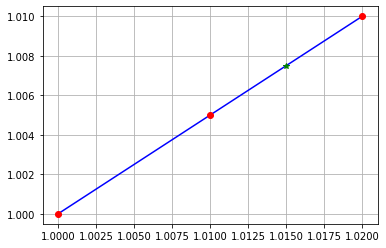

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def interpNewton(x, y, xi, grau):
  #Número de dados
  n = len(x)
  #Inicialização da diferença dividida: n x n
  fdd = [[None for x in range(n)] for x in range(n)]
  #Valores da função f(X) em vários pontos
  yint = [None for x in range(n)]
    
  #Encontrando diferenças divididas.
  for i in range(n):
    fdd[i][0] = y[i]
  for j in range(1,n):
    for i in range(n-j):
      fdd[i][j] = (fdd[i+1][j-1] - fdd[i][j-1])/(x[i+j]-x[i])
    
  # Imprimindo diferenças divididas.
  fdd_table = pd.DataFrame(fdd)
  #print(fdd_table)
    
  #Interpolação para xi.
  xterm = 1
  yint = fdd[0][0]
  for order in range(1, grau+1):
    xterm = xterm * (xi - x[order-1])
    yint = yint + fdd[0][order]*xterm
    
  #Retornando g(xi).
  return yint


x  = [1, 1.01, 1.02]
y  = [1, 1.005, 1.01]
xp = 1.015
grau = 2
yp = interpNewton(x, y, xp, grau)

# Valor interpolado encontrado
print("Valor interpolado encontrado")
print('g(%.3f) = %.3f' % (xp, yp))

t  = np.arange(1, 1.021, 0.001)
yt = []
for i in t:
  yt.append(interpNewton(x, y, i, grau))
plt.plot(t,yt,'b-')
plt.plot(x,y,'ro')
plt.plot(xp,yp,'g*')
plt.grid()
plt.show()

# 5. Interpolação forma de Gregory-Newton (usa diferenças simples)

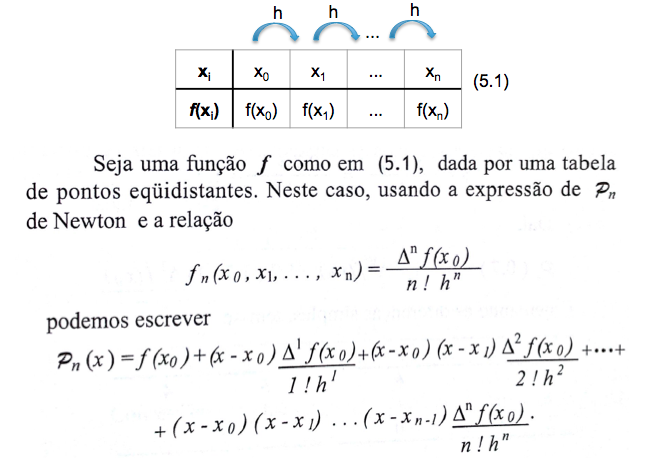

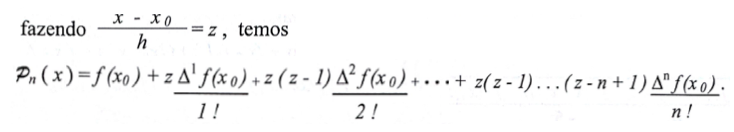

**Abaixo está a implementação do método de interpolação Gregory-Newton.** 


# Exemplo(3): 

Para os valores tabelados abaixo, encontre f(52), f(47) e f(58) utilizando o método de interpolação de Gregory-Newton.

>  x |   45   |   50   |   55   |  60
>--- | ------ | ------ | ------ | ------
>f(x)| 0.7071 | 0.7660 | 0.8192 | 0.8660

In [19]:
# Interpolação de Gregory-Newton 
 
# calculando z mencionado na fórmula 
def z_cal(z, n):
    temp = z;
    for i in range(1, n):
        temp = temp * (z - i);
    return temp;
 
# cálculo do fatorial de um determinado número n
def fact(n):
    f = 1;
    for i in range(2, n + 1):
        f *= i;
    return f;
  
# Número de valores dados
#n = 4;
x = [ 45, 50, 55, 60 ];
n = len(x)
     
# y[][] é usado para a tabela de diferença
# com y[][0] usado para entrada
y = [[0 for i in range(n)]
        for j in range(n)];
y[0][0] = 0.7071;
y[1][0] = 0.7660;
y[2][0] = 0.8192;
y[3][0] = 0.8660;
 
# Calculando a diferença de Gregory-Newton
# tabela
for i in range(1, n):
    for j in range(n - i):
        y[j][i] = y[j + 1][i - 1] - y[j][i - 1];
 
# Exibindo a tabela de diferenças 
for i in range(n):
    print(x[i], end = "\t");
    for j in range(n - i):
        print(y[i][j], end = "\t");
    print("");
 
# Valor para interpolar (exemplo):
value = 52;     ## escolha outros valores no intervalo para interpolar
 
# inicializando z e soma
sum = y[0][0];
z = (value - x[0]) / (x[1] - x[0]);  ## distância entre os pontos: h = x[1] - x[0]
for i in range(1,n):
    sum = sum + (z_cal(z, i) * y[0][i]) / fact(i);
 
print("\nValor em", value,
      "é", round(sum, 6));
 

45	0.7071	0.05890000000000006	-0.005700000000000038	-0.0007000000000000339	
50	0.766	0.053200000000000025	-0.006400000000000072	
55	0.8192	0.04679999999999995	
60	0.866	

Valor em 52 é 0.788003


In [20]:
0.766 - 0.7071

0.05890000000000006

# Exemplo (4) (do Exemplo (2))

Para os valores tabelados abaixo, encontre f(1.015), f(1.001) e f(1.018) utilizando o método de interpolação de Gregory-Newton.

>  x |   1  |  1.01  |  1.02
>--- | ---- |  ----  |  ----
>f(x)|   1  |  1.005 |  1.01


In [21]:
# Interpolação de Gregory-Newton 
 
# calculando z mencionado na fórmula 
def z_cal(z, n):
    temp = z;
    for i in range(1, n):
        temp = temp * (z - i);
    return temp;
 
# cálculo do fatorial de um determinado número n
def fact(n):
    f = 1;
    for i in range(2, n + 1):
        f *= i;
    return f;
  
# Número de valores dados
x = [ 1, 1.01, 1.02 ];
n = len(x)
     
# y[][] é usado para a tabela de diferença
# com y[][0] usado para entrada
y = [[0 for i in range(n)]
        for j in range(n)];
y[0][0] = 1;
y[1][0] = 1.005;
y[2][0] = 1.01;
 
# Calculando a diferença de Gregory-Newton
# tabela
for i in range(1, n):
    for j in range(n - i):
        y[j][i] = y[j + 1][i - 1] - y[j][i - 1];
 
# Exibindo a tabela de diferenças 
for i in range(n):
    print(x[i], end = "\t");
    for j in range(n - i):
        print(y[i][j], end = "\t");
    print("");
 
# Valor para interpolar (exemplo):
value = 1.015;     ## escolha outros valores no intervalo para interpolar
 
# inicializando z e soma
sum = y[0][0];
z = (value - x[0]) / (x[1] - x[0]);  ## distância entre os pontos: h = x[1] - x[0]
for i in range(1,n):
    sum = sum + (z_cal(z, i) * y[0][i]) / fact(i);
 
print("\nValor em", value,
      "é", round(sum, 6));

1	1	0.004999999999999893	2.220446049250313e-16	
1.01	1.005	0.0050000000000001155	
1.02	1.01	

Valor em 1.015 é 1.0075


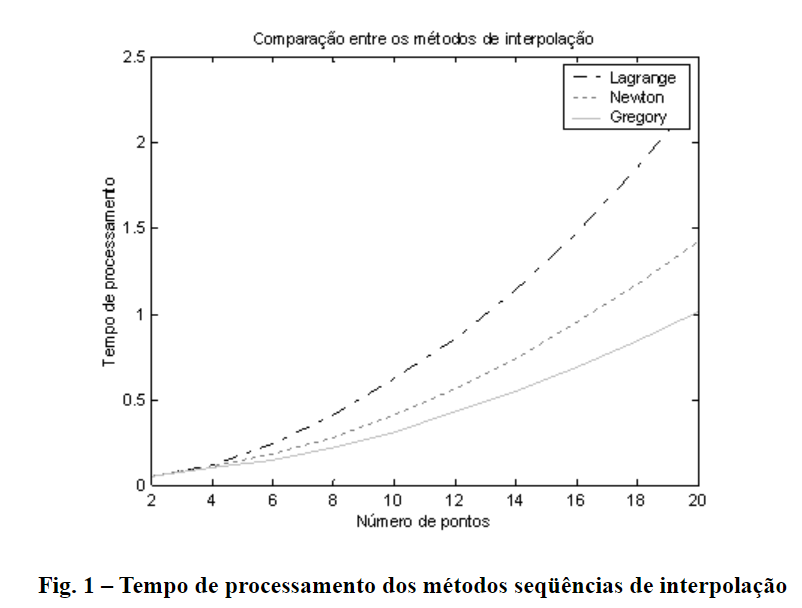

# Exercícios

1) De uma função f obteve-se o tabelamento

>  x |  -2  |  0   |   1  |  2
>--- | ---- | ---- | ---- | ----
>f(x)|  12  |  -4  |  -3  |  12

Calcule, aproximadamente, o valor de f(0,5), usando um dos "métodos" de interpolação de Newton ou Gregory-Newton, de dois modos:


*   a) Usando os três primeiros pontos da tabela dada;
*   b) Usando os três últimos pontos da tabela dada;
*   c) Faça comentários acerca dos resultados obtidos.



2) Usando a forma de Newton ou Gregory-Newton para p3(x) obtenha uma aproximação para f(2.7), onde f(x) é a função tabelada a seguir:

>  x |    1   |    2   |    3   |    4   |   5
>--- | ------ | ------ | ------ | ------ | ------
>f(x)|    0   | 1.3863 | 2.1972 | 2.7726 | 3.2189